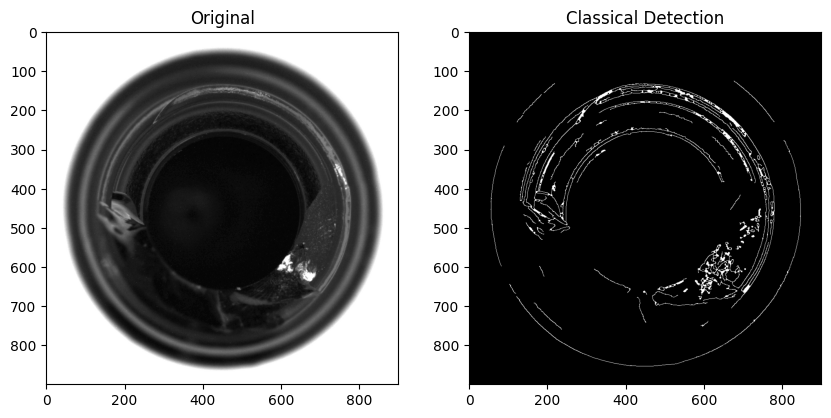

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_crack_classical(image_path):
    img = cv2.imread(image_path, 0)

    # Blur to remove noise (texture of metal/concrete)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # Contrast Enhancement (CLAHE - crucial for metallic surfaces)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blurred)

    # Edge Detection (Canny)
    # Lower/Upper thresholds determine what is considered an "edge"
    edges = cv2.Canny(enhanced, 50, 150)

    # Morphological Closing (Connects broken crack parts)
    kernel = np.ones((3,3), np.uint8)
    closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
    ax[1].imshow(closed_edges, cmap='gray'); ax[1].set_title("Classical Detection")
    plt.show()

detect_crack_classical('/content/drive/MyDrive/bottle/test/broken_large/001.png')